In [1]:
!pip install torch torchvision matplotlib seaborn scikit-learn


In [ ]:
!unzip deepfake_dataset.zip


unzip:  cannot find or open deepfake_dataset.zip, deepfake_dataset.zip.zip or deepfake_dataset.zip.ZIP.


In [ ]:
!unzip fake-news-detector.zip


unzip:  cannot find or open fake-news-detector.zip, fake-news-detector.zip.zip or fake-news-detector.zip.ZIP.


In [ ]:
!ls


sample_data


In [ ]:
from google.colab import files
uploaded = files.upload()


TypeError: 'NoneType' object is not subscriptable

In [ ]:
!ls


In [ ]:
from google.colab import files
uploaded = files.upload()


In [ ]:
from google.colab import files
files.upload()


In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!pip install kaggle


In [ ]:
!kaggle datasets list


In [ ]:
!kaggle datasets download -d dataset-owner/dataset-name


In [ ]:
!ls


In [ ]:
from google.colab import files
uploaded = files.upload()


In [ ]:
# Step 1: Upload your CSV file
from google.colab import files
import pandas as pd

uploaded = files.upload()  # Choose your CSV file
filename = list(uploaded.keys())[0]

# Step 2: Load the dataset
df = pd.read_csv(filename)
print("Dataset preview:")
print(df.head())

# Step 3: Basic info & cleaning
print("\nDataset info:")
print(df.info())

# Drop duplicates and missing values if any
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)
print("\nAfter cleaning:")
print(df.info())

# Step 4: Encode labels (if they are text)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])  # 'fake'/'real' → 0/1
print("\nLabel encoding mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# Step 5: Split data into train and test
from sklearn.model_selection import train_test_split

X = df['text']  # News content
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTraining samples: {len(X_train)}, Test samples: {len(X_test)}")

# Step 6: Text vectorization using TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("\nTF-IDF shape:")
print("X_train:", X_train_tfidf.shape)
print("X_test:", X_test_tfidf.shape)

# ✅ Your data is ready for model training!
# Example: train a simple Logistic Regression model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


In [ ]:
import zipfile
import os

# Unzip the file
with zipfile.ZipFile(filename, 'r') as zip_ref:
    zip_ref.extractall("dataset")  # Extracts all files into 'dataset' folder

# List files inside the folder
os.listdir("dataset")


In [ ]:
import os
import pandas as pd
import zipfile

# Step 1: Extract the ZIP
with zipfile.ZipFile("archive (1).zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

# Step 2: Prepare lists to hold data
texts = []
labels = []

# Read REAL news
for filename in os.listdir("dataset/training_real"):
    file_path = os.path.join("dataset/training_real", filename)
    with open(file_path, 'r', encoding='utf-8') as f:
        texts.append(f.read())
        labels.append(1)  # Real news = 1

# Read FAKE news
for filename in os.listdir("dataset/training_fake"):
    file_path = os.path.join("dataset/training_fake", filename)
    with open(file_path, 'r', encoding='utf-8') as f:
        texts.append(f.read())
        labels.append(0)  # Fake news = 0

# Step 3: Create DataFrame
df = pd.DataFrame({'text': texts, 'label': labels})
print("Dataset preview:")
print(df.head())
print("\nDataset info:")
print(df.info())


In [ ]:
# =========================
# Step 1: Upload ZIP
# =========================
from google.colab import files
import zipfile
import os
import pandas as pd

uploaded = files.upload()  # Upload your archive (1).zip
zip_filename = list(uploaded.keys())[0]

# Extract the ZIP
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Files extracted:", os.listdir("dataset"))

# =========================
# Step 2: Read all text files into a DataFrame
# =========================
texts = []
labels = []

def read_file(file_path):
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            return f.read()
    except UnicodeDecodeError:
        with open(file_path, 'r', encoding='latin1') as f:
            return f.read()

# Real news
for filename in os.listdir("dataset/training_real"):
    file_path = os.path.join("dataset/training_real", filename)
    texts.append(read_file(file_path))
    labels.append(1)

# Fake news
for filename in os.listdir("dataset/training_fake"):
    file_path = os.path.join("dataset/training_fake", filename)
    texts.append(read_file(file_path))
    labels.append(0)

df = pd.DataFrame({'text': texts, 'label': labels})
print("Dataset preview:")
print(df.head())
print("\nDataset info:")
print(df.info())

# =========================
# Step 3: Clean data
# =========================
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

# =========================
# Step 4: Train-test split
# =========================
from sklearn.model_selection import train_test_split

X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")

# =========================
# Step 5: TF-IDF Vectorization
# =========================
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# =========================
# Step 6: Classical ML Models
# =========================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

results = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"\n{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Fake","Real"], yticklabels=["Fake","Real"])
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# =========================
# Step 7: LSTM Model
# =========================
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# Tokenization
tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

max_len = 200
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

# Build LSTM
model_lstm = Sequential([
    Embedding(input_dim=5000, output_dim=64, input_length=max_len),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model_lstm.summary()

# Train LSTM
history = model_lstm.fit(X_train_pad, y_train, epochs=5, batch_size=64, validation_split=0.2)

# Evaluate LSTM
loss, accuracy = model_lstm.evaluate(X_test_pad, y_test)
print("\nLSTM Test Accuracy:", accuracy)
results["LSTM"] = accuracy

# =========================
# Step 8: Compare All Models
# =========================
plt.figure(figsize=(8,5))
plt.bar(results.keys(), results.values(), color='skyblue')
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.ylim(0,1)
plt.show()


In [ ]:
!ls


In [ ]:
!ls dataset


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


In [ ]:
dataset = datasets.ImageFolder(
    root="dataset",
    transform=transform
)

print("Classes:", dataset.classes)


In [ ]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)


In [4]:
model = models.resnet18(pretrained=True)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Replace final fully connected layer
model.fc = nn.Linear(model.fc.in_features, 2)

model = model.to(device)

print("Model ready.")


NameError: name 'device' is not defined

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [9]:
model = models.resnet18(pretrained=True)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, 2)

model = model.to(device)

print("Model ready.")


Model ready.


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [8]:
model = model.to(device)
print("Model ready.")


Model ready.


In [ ]:
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")


In [14]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


In [15]:
dataset = datasets.ImageFolder(
    root="dataset",
    transform=transform
)

print("Classes:", dataset.classes)


FileNotFoundError: [Errno 2] No such file or directory: 'dataset'

In [12]:
!kaggle datasets download -d ciplab/real-and-fake-face-detection


Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/cli.py", line 68, in main
    out = args.func(**command_args)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 1741, in dataset_download_cli
    with self.build_kaggle_client() as kaggle:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 688, in build_kaggle_client
    username=self.config_values['username'],
             ~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
KeyError: 'username'


In [7]:
!unzip real-and-fake-face-detection.zip


unzip:  cannot find or open real-and-fake-face-detection.zip, real-and-fake-face-detection.zip.zip or real-and-fake-face-detection.zip.ZIP.


In [ ]:
!ls


kaggle.json	    real_and_fake_face_detection      sample_data
real_and_fake_face  real-and-fake-face-detection.zip


In [ ]:
!unzip real-and-fake-face-detection.zip


Archive:  real-and-fake-face-detection.zip
replace real_and_fake_face/training_fake/easy_100_1111.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [11]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"barkha10","key":"8d9fcf5f66bc97f8d7d22428edfc1d67"}'}

In [26]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [25]:
!pip install kaggle


In [27]:
!kaggle datasets download -d ciplab/real-and-fake-face-detection


Dataset URL: https://www.kaggle.com/datasets/ciplab/real-and-fake-face-detection
License(s): CC-BY-NC-SA-4.0
 80% 344M/431M [00:02<00:00, 99.4MB/s]
100% 431M/431M [00:02<00:00, 165MB/s] 


In [28]:
!ls


'kaggle (1).json'   kaggle.json			       sample_data
'kaggle (2).json'   real-and-fake-face-detection.zip


In [29]:
!unzip real-and-fake-face-detection.zip


Archive:  real-and-fake-face-detection.zip
  inflating: real_and_fake_face/training_fake/easy_100_1111.jpg  
  inflating: real_and_fake_face/training_fake/easy_101_0010.jpg  
  inflating: real_and_fake_face/training_fake/easy_102_0101.jpg  
  inflating: real_and_fake_face/training_fake/easy_103_1111.jpg  
  inflating: real_and_fake_face/training_fake/easy_104_1000.jpg  
  inflating: real_and_fake_face/training_fake/easy_105_1100.jpg  
  inflating: real_and_fake_face/training_fake/easy_106_0011.jpg  
  inflating: real_and_fake_face/training_fake/easy_107_1011.jpg  
  inflating: real_and_fake_face/training_fake/easy_108_1111.jpg  
  inflating: real_and_fake_face/training_fake/easy_109_1111.jpg  
  inflating: real_and_fake_face/training_fake/easy_10_0001.jpg  
  inflating: real_and_fake_face/training_fake/easy_110_0001.jpg  
  inflating: real_and_fake_face/training_fake/easy_111_1101.jpg  
  inflating: real_and_fake_face/training_fake/easy_112_1001.jpg  
  inflating: real_and_fake_face/tr

In [30]:
!ls


'kaggle (1).json'   real_and_fake_face		       sample_data
'kaggle (2).json'   real_and_fake_face_detection
 kaggle.json	    real-and-fake-face-detection.zip


In [31]:
!ls


'kaggle (1).json'   real_and_fake_face		       sample_data
'kaggle (2).json'   real_and_fake_face_detection
 kaggle.json	    real-and-fake-face-detection.zip


In [32]:
!ls -R


.:
'kaggle (1).json'   real_and_fake_face		       sample_data
'kaggle (2).json'   real_and_fake_face_detection
 kaggle.json	    real-and-fake-face-detection.zip

./real_and_fake_face:
training_fake  training_real

./real_and_fake_face/training_fake:
easy_10_0001.jpg   hard_100_1111.jpg  mid_100_1110.jpg	mid_315_1101.jpg
easy_100_1111.jpg  hard_101_0011.jpg  mid_101_1111.jpg	mid_316_1111.jpg
easy_101_0010.jpg  hard_10_1111.jpg   mid_10_1111.jpg	mid_317_1101.jpg
easy_102_0101.jpg  hard_102_1001.jpg  mid_102_1100.jpg	mid_318_1111.jpg
easy_103_1111.jpg  hard_103_1101.jpg  mid_103_1111.jpg	mid_319_1111.jpg
easy_104_1000.jpg  hard_104_1001.jpg  mid_104_1100.jpg	mid_320_1111.jpg
easy_105_1100.jpg  hard_105_1011.jpg  mid_105_1101.jpg	mid_321_1110.jpg
easy_106_0011.jpg  hard_106_1100.jpg  mid_106_0001.jpg	mid_32_1111.jpg
easy_107_1011.jpg  hard_107_1111.jpg  mid_107_0010.jpg	mid_322_1111.jpg
easy_108_1111.jpg  hard_108_1111.jpg  mid_108_1110.jpg	mid_323_1101.jpg
easy_109_1111.jpg  hard_109_1100

In [33]:
!ls real_and_fake_face


training_fake  training_real


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

dataset = datasets.ImageFolder(
    root="real_and_fake_face",
    transform=transform
)

print("Classes:", dataset.classes)
print("Total images:", len(dataset))


In [ ]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))


In [ ]:
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)


NameError: name 'nn' is not defined

In [ ]:
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")


In [ ]:
model.eval()

predictions = []
true_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(true_labels, predictions)
print("Validation Accuracy:", accuracy)


In [ ]:
# Unfreeze last 2 layers
for name, param in model.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False


In [ ]:
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0001)


In [ ]:
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")


In [ ]:
model.eval()

predictions = []
true_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(true_labels, predictions)
print("Validation Accuracy:", accuracy)


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


NameError: name 'transforms' is not defined

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

NameError: name 'transforms' is not defined

In [16]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader

In [17]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [34]:
dataset = datasets.ImageFolder(
    root="real_and_fake_face",
    transform=transform
)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

In [19]:
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle (1).json


In [35]:
import zipfile

with zipfile.ZipFile("real_and_fake_face.zip", 'r') as zip_ref:
    zip_ref.extractall()

FileNotFoundError: [Errno 2] No such file or directory: 'real_and_fake_face.zip'

In [36]:
!ls real_and_fake_face


training_fake  training_real


In [37]:
dataset = datasets.ImageFolder(
    root="real_and_fake_face",
    transform=transform
)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

print("Total images:", len(dataset))
print("Train size:", train_size)
print("Validation size:", val_size)

Total images: 2041
Train size: 1632
Validation size: 409


In [38]:
for name, param in model.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001
)

In [39]:
epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")

NameError: name 'criterion' is not defined

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets, models
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score

In [23]:
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle (2).json


In [40]:
import zipfile

with zipfile.ZipFile("real_and_fake_face.zip", 'r') as zip_ref:
    zip_ref.extractall()

FileNotFoundError: [Errno 2] No such file or directory: 'real_and_fake_face.zip'

In [41]:
!ls

'kaggle (1).json'   real_and_fake_face		       sample_data
'kaggle (2).json'   real_and_fake_face_detection
 kaggle.json	    real-and-fake-face-detection.zip


In [42]:
dataset = datasets.ImageFolder(
    root="real_and_fake_face",
    transform=transform
)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

print("Total images:", len(dataset))
print("Train size:", train_size)
print("Validation size:", val_size)

Total images: 2041
Train size: 1632
Validation size: 409


In [43]:
model = models.resnet18(pretrained=True)

model.fc = nn.Linear(model.fc.in_features, 2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

print("Model ready")

Model ready


In [44]:
for name, param in model.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

In [45]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001
)

In [46]:
epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")

Epoch 1/10, Loss: 0.6652
Epoch 2/10, Loss: 0.5089
Epoch 3/10, Loss: 0.4106
Epoch 4/10, Loss: 0.3123
Epoch 5/10, Loss: 0.2426
Epoch 6/10, Loss: 0.2020
Epoch 7/10, Loss: 0.1678
Epoch 8/10, Loss: 0.1365
Epoch 9/10, Loss: 0.1286
Epoch 10/10, Loss: 0.1166


In [47]:
model.eval()

predictions = []
true_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(true_labels, predictions)

print("Validation Accuracy:", accuracy)

Validation Accuracy: 0.6405867970660146


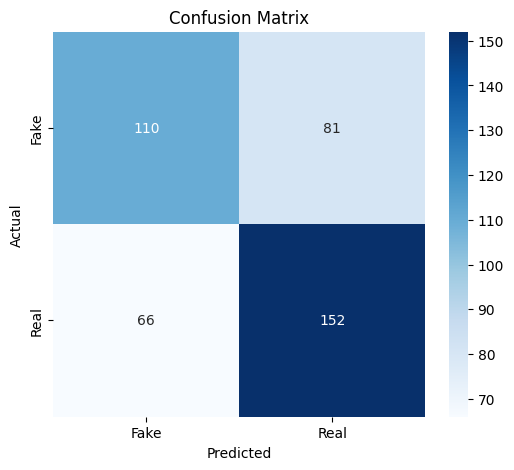

In [48]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fake","Real"],
            yticklabels=["Fake","Real"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [49]:
from sklearn.metrics import classification_report

print(classification_report(true_labels, predictions))

              precision    recall  f1-score   support

           0       0.62      0.58      0.60       191
           1       0.65      0.70      0.67       218

    accuracy                           0.64       409
   macro avg       0.64      0.64      0.64       409
weighted avg       0.64      0.64      0.64       409



In [50]:
from PIL import Image
import matplotlib.pyplot as plt

def predict_image(image_path):
    model.eval()

    img = Image.open(image_path).convert("RGB")
    img = transform(img)
    img = img.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img)
        _, pred = torch.max(output, 1)

    if pred.item() == 0:
        print("Prediction: FAKE FACE")
    else:
        print("Prediction: REAL FACE")

    plt.imshow(Image.open(image_path))
    plt.axis("off")
    plt.show()

In [51]:
from PIL import Image
import matplotlib.pyplot as plt

def predict_image(image_path):
    model.eval()

    img = Image.open(image_path).convert("RGB")
    img = transform(img)
    img = img.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img)
        _, pred = torch.max(output, 1)

    if pred.item() == 0:
        print("Prediction: FAKE FACE")
    else:
        print("Prediction: REAL FACE")

    plt.imshow(Image.open(image_path))
    plt.axis("off")
    plt.show()

Prediction: REAL FACE


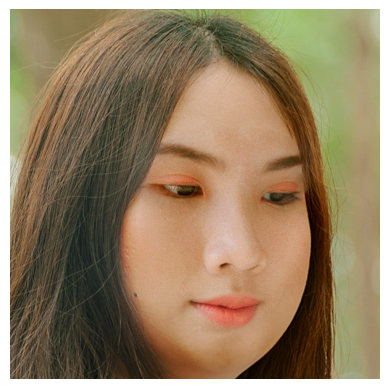

In [52]:
predict_image("real_and_fake_face/training_fake/easy_100_1111.jpg")

In [53]:
torch.save(model.state_dict(), "deepfake_model.pth")